# 01 — Data Understanding
## Climate Change: Earth Surface Temperature Analysis

**Project Leader:** Sekai  
**Mục tiêu:** Hiểu bài toán, cấu trúc và chất lượng của 5 bộ dữ liệu nhiệt độ; xác định bảng chính, target, grain, key và những việc cần chuẩn bị trước PostgreSQL Pipeline.


## 1. Hiểu bài toán

### 1.1 Bài toán AI

Dự án phân tích sự thay đổi nhiệt độ bề mặt Trái Đất theo thời gian và địa điểm, sau đó xây dựng mô hình Machine Learning để dự đoán nhiệt độ trung bình. Kết quả có thể hỗ trợ nhận biết xu hướng nóng lên, so sánh khu vực và minh họa dự báo trên ứng dụng.

### 1.2 Target và đơn vị quan sát

- **Target chính:** `AverageTemperature` — nhiệt độ trung bình theo tháng, đơn vị °C.
- **Bảng chính cho ML:** `GlobalLandTemperaturesByCountry.csv`.
- **Một dòng của bảng chính:** một quốc gia trong một tháng.
- **Khóa logic dự kiến:** `dt + Country`.

Bảng Country được chọn vì có phạm vi địa lý rộng, số bản ghi đủ lớn, target rõ ràng và kích thước phù hợp để thử nhiều mô hình. Đây là giả định thiết kế ban đầu; hiệu quả của target và feature sẽ được kiểm chứng ở Notebook 04–06.


## 2. Chuẩn bị môi trường

Notebook chỉ đọc dữ liệu raw, không ghi đè hoặc đổi tên cột trong CSV. Các file lớn được quét theo từng chunk để giới hạn RAM.


In [1]:
from pathlib import Path
import csv
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2563EB', '#0EA5E9', '#14B8A6', '#F59E0B', '#EF4444']
CHUNK_SIZE = 250_000

print('Pandas:', pd.__version__)
print('Chunk size:', f'{CHUNK_SIZE:,}', 'dòng')


Pandas: 3.0.3
Chunk size: 250,000 dòng


### Giải thích code

- `Path` giúp xử lý đường dẫn giống nhau trên Windows, macOS và Linux.
- `display()` hiển thị DataFrame đẹp trong Jupyter; nếu chạy bằng Python thường thì tự chuyển sang `print()`.
- `CHUNK_SIZE = 250_000` nghĩa là mỗi lần chỉ đưa 250.000 dòng của file lớn vào RAM.
- `pd.set_option()` chỉ thay đổi cách hiển thị, không làm thay đổi dữ liệu.


## 3. Tìm và xác nhận 5 file dữ liệu


In [2]:
EXPECTED_FILES = [
    'GlobalLandTemperaturesByCity.csv',
    'GlobalLandTemperaturesByCountry.csv',
    'GlobalLandTemperaturesByMajorCity.csv',
    'GlobalLandTemperaturesByState.csv',
    'GlobalTemperatures.csv',
]

def find_data_directory(expected_files):
    candidates = [
        Path('data/raw'), Path('../data/raw'), Path('../../data/raw'),
        Path('upload'), Path('../upload'),
    ]
    checked = []

    for candidate in candidates:
        candidate = candidate.resolve()
        checked.append(str(candidate))
        if candidate.is_dir() and all((candidate / name).is_file() for name in expected_files):
            return candidate

    raise FileNotFoundError(
        'Không tìm thấy đủ 5 file CSV. Hãy đặt file trong data/raw/.\n'
        + 'Đã kiểm tra:\n- ' + '\n- '.join(checked)
    )

DATA_DIR = find_data_directory(EXPECTED_FILES)
FILE_PATHS = {name: DATA_DIR / name for name in EXPECTED_FILES}
MAIN_FILE = 'GlobalLandTemperaturesByCountry.csv'
MAIN_PATH = FILE_PATHS[MAIN_FILE]

print('Thư mục dữ liệu:', DATA_DIR)
print('Số file tìm thấy:', len(FILE_PATHS))
print('Bảng chính:', MAIN_FILE)


Thư mục dữ liệu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\raw
Số file tìm thấy: 5
Bảng chính: GlobalLandTemperaturesByCountry.csv


### Giải thích code

Hàm thử lần lượt các vị trí thường gặp. Điều kiện `all(...)` chỉ trả về `True` khi cả 5 file đều tồn tại, nhờ vậy notebook không âm thầm chạy thiếu bảng. `resolve()` chuyển đường dẫn tương đối thành đường dẫn tuyệt đối để dễ kiểm tra lỗi.


## 4. Danh sách bảng, vai trò, grain và key

Năm file không phải một schema quan hệ chuẩn gồm fact–dimension. Chúng là các **bảng fact nhiệt độ ở những cấp địa lý khác nhau**. Vì vậy không nên nối tất cả thành một bảng lớn ngay từ đầu.


In [3]:
table_catalog = pd.DataFrame([
    {
        'file': 'GlobalLandTemperaturesByCountry.csv',
        'table_role': 'Main fact table',
        'grain': '1 quốc gia trong 1 tháng',
        'candidate_key': 'dt + Country',
        'project_use': 'ML chính, so sánh quốc gia',
    },
    {
        'file': 'GlobalTemperatures.csv',
        'table_role': 'Global summary fact',
        'grain': 'Toàn cầu trong 1 tháng',
        'candidate_key': 'dt',
        'project_use': 'Xu hướng toàn cầu, benchmark',
    },
    {
        'file': 'GlobalLandTemperaturesByState.csv',
        'table_role': 'Supporting fact table',
        'grain': '1 bang/tỉnh trong 1 tháng',
        'candidate_key': 'dt + Country + State',
        'project_use': 'Phân tích khu vực hành chính',
    },
    {
        'file': 'GlobalLandTemperaturesByCity.csv',
        'table_role': 'Supporting fact table',
        'grain': '1 thành phố–tọa độ trong 1 tháng',
        'candidate_key': 'dt + Country + City + Latitude + Longitude',
        'project_use': 'Phân tích chi tiết và dashboard',
    },
    {
        'file': 'GlobalLandTemperaturesByMajorCity.csv',
        'table_role': 'Supporting fact table',
        'grain': '1 thành phố lớn–tọa độ trong 1 tháng',
        'candidate_key': 'dt + Country + City + Latitude + Longitude',
        'project_use': 'So sánh các đô thị lớn',
    },
])
display(table_catalog)


,file,table_role,grain,candidate_key,project_use
0,GlobalLandTemperaturesByCountry.csv,Main fact table,1 quốc gia trong 1 tháng,dt + Country,"ML chính, so sánh quốc gia"
1,GlobalTemperatures.csv,Global summary fact,Toàn cầu trong 1 tháng,dt,"Xu hướng toàn cầu, benchmark"
2,GlobalLandTemperaturesByState.csv,Supporting fact table,1 bang/tỉnh trong 1 tháng,dt + Country + State,Phân tích khu vực hành chính
3,GlobalLandTemperaturesByCity.csv,Supporting fact table,1 thành phố–tọa độ trong 1 tháng,dt + Country + City + Latitude + Longitude,Phân tích chi tiết và dashboard
4,GlobalLandTemperaturesByMajorCity.csv,Supporting fact table,1 thành phố lớn–tọa độ trong 1 tháng,dt + Country + City + Latitude + Longitude,So sánh các đô thị lớn


### Nhận xét

- Country là bảng trung tâm của bài toán ML, nhưng không phải cha vật lý của mọi bảng.
- State và City có thể liên kết phân tích với Country qua `dt + Country`.
- Major City là một góc nhìn tập trung vào đô thị lớn, không nên coi là dimension của City.
- Tên City có thể trùng giữa nhiều vị trí, nên candidate key cần thêm `Latitude` và `Longitude` thay vì chỉ dùng tên thành phố. Trong CSV hiện tại, các cột địa lý dùng đúng dạng `Country`, `City`, `Latitude`, `Longitude`.
- Global chỉ có `dt`, nên khi join với Country sẽ tạo cùng một chỉ số toàn cầu lặp lại cho mọi quốc gia trong cùng tháng. Điều này chỉ nên làm khi thật sự cần tạo feature benchmark.


## 5. Data Dictionary


In [4]:
data_dictionary = pd.DataFrame([
    ['dt', 'Thời điểm ghi nhận theo tháng', 'Date', 'Month', 'Time / key'],
    ['AverageTemperature', 'Nhiệt độ trung bình ước tính', 'Numeric', '°C', 'Target / measure'],
    ['AverageTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ trung bình', 'Numeric', '°C', 'Quality measure'],
    ['Country', 'Tên quốc gia', 'Category', '—', 'Location / key'],
    ['State', 'Bang, tỉnh hoặc khu vực hành chính', 'Category', '—', 'Location / key'],
    ['City', 'Tên thành phố', 'Category', '—', 'Location / key'],
    ['Latitude', 'Vĩ độ, có hậu tố N hoặc S', 'Text coordinate', 'Degree', 'Location'],
    ['Longitude', 'Kinh độ, có hậu tố E hoặc W', 'Text coordinate', 'Degree', 'Location'],
    ['LandAverageTemperature', 'Nhiệt độ trung bình toàn cầu trên đất liền', 'Numeric', '°C', 'Global target/measure'],
    ['LandAverageTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ đất liền', 'Numeric', '°C', 'Quality measure'],
    ['LandMaxTemperature', 'Nhiệt độ cực đại trung bình trên đất liền', 'Numeric', '°C', 'Global measure'],
    ['LandMaxTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ cực đại', 'Numeric', '°C', 'Quality measure'],
    ['LandMinTemperature', 'Nhiệt độ cực tiểu trung bình trên đất liền', 'Numeric', '°C', 'Global measure'],
    ['LandMinTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ cực tiểu', 'Numeric', '°C', 'Quality measure'],
    ['LandAndOceanAverageTemperature', 'Nhiệt độ trung bình kết hợp đất liền và đại dương', 'Numeric', '°C', 'Global measure'],
    ['LandAndOceanAverageTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ đất liền và đại dương', 'Numeric', '°C', 'Quality measure'],
], columns=['column', 'meaning', 'expected_group', 'unit', 'role'])
display(data_dictionary)


,column,meaning,expected_group,unit,role
0,dt,Thời điểm ghi nhận theo tháng,Date,Month,Time / key
1,AverageTemperature,Nhiệt độ trung bình ước tính,Numeric,°C,Target / measure
2,AverageTemperatureUncertainty,Độ không chắc chắn của nhiệt độ trung bình,Numeric,°C,Quality measure
3,Country,Tên quốc gia,Category,—,Location / key
4,State,"Bang, tỉnh hoặc khu vực hành chính",Category,—,Location / key
5,City,Tên thành phố,Category,—,Location / key
6,Latitude,"Vĩ độ, có hậu tố N hoặc S",Text coordinate,Degree,Location
7,Longitude,"Kinh độ, có hậu tố E hoặc W",Text coordinate,Degree,Location
8,LandAverageTemperature,Nhiệt độ trung bình toàn cầu trên đất liền,Numeric,°C,Global target/measure
9,LandAverageTemperatureUncertainty,Độ không chắc chắn của nhiệt độ đất liền,Numeric,°C,Quality measure


### Nhận xét

Data Dictionary sử dụng đúng tên cột trong năm CSV raw: `dt` viết thường, còn các cột đo lường và địa lý dùng PascalCase như `AverageTemperature`, `Country`, `City`, `Latitude`, `Longitude`. Việc ánh xạ sang `snake_case` thuộc PostgreSQL/Cleaning và cần được ghi rõ mà không sửa CSV nguồn. `Latitude`/`Longitude` vẫn là chuỗi vì có hậu tố hướng N/S/E/W, nên phải tách hướng và dấu trước khi chuyển sang số.


## 6. Kiểm tra nhanh schema và tính toàn vẹn của từng file


In [5]:
def inspect_file_tail(path, tail_bytes=65_536):
    size_bytes = path.stat().st_size

    with path.open('rb') as file:
        header = file.readline().decode('utf-8-sig', errors='replace').rstrip('\r\n')
        if size_bytes > tail_bytes:
            file.seek(-tail_bytes, 2)
        tail = file.read()

    last_line = tail.decode('utf-8', errors='replace').splitlines()[-1]
    header_fields = len(next(csv.reader([header])))
    last_fields = len(next(csv.reader([last_line])))

    return {
        'file': path.name,
        'file_size_mb': size_bytes / 1024**2,
        'header_fields': header_fields,
        'last_row_fields': last_fields,
        'ends_with_newline': tail.endswith((b'\n', b'\r')),
        'field_count_status': 'OK' if last_fields == header_fields else 'Cần kiểm tra lại bản sao CSV',
    }

integrity_df = pd.DataFrame(inspect_file_tail(path) for path in FILE_PATHS.values())
display(integrity_df)


,file,file_size_mb,header_fields,last_row_fields,ends_with_newline,field_count_status
0,GlobalLandTemperaturesByCity.csv,508.1467,7,7,True,OK
1,GlobalLandTemperaturesByCountry.csv,21.6297,4,4,True,OK
2,GlobalLandTemperaturesByMajorCity.csv,13.4834,7,7,True,OK
3,GlobalLandTemperaturesByState.csv,29.3447,5,5,True,OK
4,GlobalTemperatures.csv,0.1963,9,9,True,OK


### Giải thích và nhận xét

Kiểm tra này so sánh số trường của header và dòng cuối. Kết quả hiện tại cho thấy cả 5 file có số trường ở dòng cuối khớp header, đều kết thúc bằng ký tự xuống dòng và nhận trạng thái `OK`; vì vậy chưa có dấu hiệu file bị cắt ở cuối hoặc sai cấu trúc dòng cuối. Đây chỉ là kiểm tra nhanh, không chứng minh mọi dòng ở giữa đều hợp lệ. File không có ký tự xuống dòng cuối vẫn có thể hợp lệ nếu dòng cuối đủ trường, nên `ends_with_newline=False` tự nó không phải lỗi.


# PHẦN A — KHẢO SÁT BẢNG CHÍNH (COUNTRY)

Bảng Country được đọc đầy đủ vì kích thước vừa phải. Các file lớn còn lại sẽ được quét theo chunk ở Phần B.


## 7. Đọc bảng chính và xem dữ liệu mẫu


In [6]:
main_raw = pd.read_csv(MAIN_PATH, low_memory=False)
main_df = main_raw.copy()

print('Shape:', main_df.shape)
display(main_df.head())
display(main_df.sample(5, random_state=42))


Shape: (577462, 4)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.3840,2.2940,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
432136,1967-02-01,-23.7140,0.3150,Russia
237733,1786-11-01,1.7970,5.8730,Hungary
144098,1956-10-01,-20.1800,0.7520,Denmark
312208,1910-08-01,28.5690,0.3880,Macau
58319,1773-10-01,10.7140,1.8610,Belgium


### Giải thích và nhận xét

`head()` giúp kiểm tra thứ tự và định dạng vài dòng đầu; `sample()` lấy ngẫu nhiên để tránh chỉ nhìn một quốc gia đầu file. `random_state=42` giúp lần chạy sau lấy đúng cùng mẫu, thuận tiện khi báo cáo nhóm. `copy()` giữ lại phiên bản raw để so sánh trước/sau chuyển kiểu.


## 8. Kích thước và bộ nhớ


In [7]:
main_memory_bytes = main_df.memory_usage(deep=True).sum()
main_size_summary = pd.DataFrame({
    'metric': ['Rows', 'Columns', 'CSV size (MB)', 'DataFrame memory (MB)'],
    'value': [
        len(main_df),
        main_df.shape[1],
        MAIN_PATH.stat().st_size / 1024**2,
        main_memory_bytes / 1024**2,
    ],
})
display(main_size_summary)

main_df.info(memory_usage='deep')


,metric,value
0,Rows,"577,462.0000"
1,Columns,4.0000
2,CSV size (MB),21.6297
3,DataFrame memory (MB),28.4114


<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 28.4 MB


### Giải thích và nhận xét

`memory_usage(deep=True)` tính cả bộ nhớ của chuỗi, chính xác hơn cách tính mặc định. Bảng Country có 577.462 dòng và 4 cột; CSV chiếm khoảng 21,63 MB, còn DataFrame dùng khoảng 28,41 MB vì pandas phải lưu index, chuỗi và mảng số trong bộ nhớ. `info()` đồng thời xác nhận hai cột số có missing, trong khi `dt` và `Country` đủ 577.462 giá trị.


## 9. Cấu trúc, kiểu dữ liệu, số giá trị khác nhau và Unique Ratio


In [8]:
dtype_counts = main_df.dtypes.astype(str).value_counts().rename_axis('dtype').reset_index(name='column_count')
display(dtype_counts)

column_profile = pd.DataFrame({
    'column': main_df.columns,
    'dtype_before': main_df.dtypes.astype(str).values,
    'non_null': main_df.notna().sum().values,
    'nunique': main_df.nunique(dropna=True).values,
})
column_profile['unique_ratio_percent'] = column_profile['nunique'] / len(main_df) * 100
display(column_profile)


,dtype,column_count
0,str,2
1,float64,2


,column,dtype_before,non_null,nunique,unique_ratio_percent
0,dt,str,577462,3239,0.5609
1,AverageTemperature,float64,544811,71085,12.3099
2,AverageTemperatureUncertainty,float64,545550,8979,1.5549
3,Country,str,577462,243,0.0421


### Giải thích và nhận xét

`nunique(dropna=True)` đếm số giá trị khác nhau và không coi NaN là một nhóm. Unique Ratio = `nunique / số dòng × 100`. Country có tỷ lệ thấp vì mỗi quốc gia lặp lại theo nhiều tháng; `dt` cũng lặp giữa các quốc gia. Vì vậy không cột đơn nào phù hợp làm primary key, nhưng tổ hợp `dt + Country` có thể là khóa logic.


## 10. Chuyển ngày và thống kê mô tả đầy đủ


In [9]:
main_df['dt'] = pd.to_datetime(main_df['dt'], errors='coerce')

numeric_describe = main_df.select_dtypes(include='number').describe().T
numeric_describe['median'] = main_df.select_dtypes(include='number').median()
numeric_describe = numeric_describe[[
    'count', 'mean', 'std', 'min', '25%', '50%', 'median', '75%', 'max'
]]
display(numeric_describe)


,count,mean,std,min,25%,50%,median,75%,max
AverageTemperature,"544,811.0000",17.1934,10.9540,-37.6580,10.0250,20.9010,20.9010,25.8140,38.8420
AverageTemperatureUncertainty,"545,550.0000",1.0191,1.2019,0.0520,0.3230,0.5710,0.5710,1.2060,15.0030


### Giải thích và nhận xét

`errors='coerce'` đổi ngày sai thành `NaT` để có thể đếm. `describe()` cung cấp count, mean, std, min, max và các phân vị 25%–50%–75%. Cột `median` được thêm riêng để người đọc thấy rõ 50% chính là trung vị. Uncertainty có mean lớn hơn median thường gợi ý phân phối lệch phải: một số quan sát lịch sử có uncertainty rất cao.


## 11. Missing Values


In [10]:
main_missing = pd.DataFrame({
    'missing_count': main_df.isna().sum(),
    'missing_percent': main_df.isna().mean() * 100,
}).sort_values('missing_percent', ascending=False)
display(main_missing)


,missing_count,missing_percent
AverageTemperature,32651,5.6542
AverageTemperatureUncertainty,31912,5.5263
dt,0,0.0000
Country,0,0.0000


### Nhận xét

`AverageTemperature` thiếu 32.651 dòng (5,6542%) và `AverageTemperatureUncertainty` thiếu 31.912 dòng (5,5263%); `dt` và `Country` không có missing. Missing target không nên được điền tùy tiện trong Notebook 01. Notebook 03 cần kiểm tra phân bố missing theo quốc gia và thời kỳ để xác định đây là thiếu có cấu trúc hay thiếu ngẫu nhiên trước khi chọn cách xử lý.


## 12. Duplicate và khóa logic


In [11]:
full_duplicate_count = int(main_df.duplicated().sum())
logical_key_duplicate_count = int(main_df.duplicated(subset=['dt', 'Country'], keep=False).sum())

duplicate_summary = pd.DataFrame({
    'check': ['Trùng toàn bộ dòng', 'Dòng thuộc khóa dt + Country bị trùng'],
    'row_count': [full_duplicate_count, logical_key_duplicate_count],
})
display(duplicate_summary)

if logical_key_duplicate_count > 0:
    display(main_df[main_df.duplicated(['dt', 'Country'], keep=False)].sort_values(['Country', 'dt']).head(20))


,check,row_count
0,Trùng toàn bộ dòng,0
1,Dòng thuộc khóa dt + Country bị trùng,0


### Giải thích và nhận xét

`duplicated()` không truyền cột sẽ kiểm tra toàn bộ dòng. Khi truyền `subset=['dt', 'Country']`, notebook kiểm tra tính duy nhất của khóa logic; kết quả hiện tại là 0 dòng trùng toàn bộ và 0 dòng vi phạm khóa `dt + Country`. `keep=False` đánh dấu tất cả dòng thuộc một nhóm trùng để dễ xem nguyên nhân, thay vì chỉ đánh dấu dòng xuất hiện sau.


## 13. Kiểm tra giá trị sai logic và bất thường sơ bộ


In [12]:
logic_checks = pd.DataFrame([
    ['Ngày không chuyển được', int(main_df['dt'].isna().sum())],
    ['Country rỗng', int((main_df['Country'].isna() | main_df['Country'].fillna('').str.strip().eq('')).sum())],
    ['Temperature < -90°C hoặc > 60°C', int((~main_df['AverageTemperature'].between(-90, 60) & main_df['AverageTemperature'].notna()).sum())],
    ['Uncertainty âm', int((main_df['AverageTemperatureUncertainty'] < 0).sum())],
    ['Target bị thiếu', int(main_df['AverageTemperature'].isna().sum())],
], columns=['logic_check', 'affected_rows'])
display(logic_checks)


,logic_check,affected_rows
0,Ngày không chuyển được,0
1,Country rỗng,0
2,Temperature < -90°C hoặc > 60°C,0
3,Uncertainty âm,0
4,Target bị thiếu,32651


### Nhận xét

Kết quả không phát hiện ngày lỗi, Country rỗng, nhiệt độ nằm ngoài ngưỡng kỹ thuật −90°C đến 60°C hoặc uncertainty âm. Chỉ có 32.651 dòng thiếu target, trùng với kiểm tra missing ở Mục 11. Khoảng nhiệt độ trên chỉ là ngưỡng kiểm tra kỹ thuật rộng, không phải quy tắc xóa outlier; Notebook 03 vẫn phải đánh giá bất thường theo địa điểm, tháng và uncertainty trước khi xử lý.


## 14. Khảo sát nhóm Category và Date


In [13]:
country_counts = main_df['Country'].value_counts(dropna=False)
display(country_counts.head(15).rename('row_count').to_frame())

date_summary = pd.DataFrame({
    'metric': ['Min date', 'Max date', 'Distinct months', 'Distinct countries'],
    'value': [
        main_df['dt'].min(),
        main_df['dt'].max(),
        main_df['dt'].nunique(),
        main_df['Country'].nunique(),
    ],
})
display(date_summary)

months_per_country = main_df.groupby('Country')['dt'].nunique()
display(months_per_country.describe().rename('months_per_country').to_frame())


,row_count
Country,
Åland,3239
Albania,3239
Andorra,3239
Austria,3239
Belarus,3239
Belgium,3239
Bosnia And Herzegovina,3239
Bulgaria,3239
Croatia,3239


,metric,value
0,Min date,1743-11-01 00:00:00
1,Max date,2013-09-01 00:00:00
2,Distinct months,3239
3,Distinct countries,243


,months_per_country
count,243.0000
mean,"2,376.3868"
std,556.8775
min,764.0000
25%,"1,965.0000"
50%,"2,277.0000"
75%,"2,761.5000"
max,"3,239.0000"


### Nhận xét

Bảng Country bao phủ từ 1743-11 đến 2013-09, gồm 3.239 tháng khác nhau và 243 giá trị Country. Số tháng theo Country dao động từ 764 đến 3.239, nên đây là panel không cân bằng; các quốc gia có lịch sử dài hơn đóng góp nhiều dòng hơn. Khi huấn luyện cần ưu tiên chia theo thời gian và kiểm soát ảnh hưởng của độ dài chuỗi, thay vì chia ngẫu nhiên toàn bộ dòng.


## 15. Khảo sát Target

Histogram cho biết hình dạng phân phối; boxplot giúp nhìn độ phân tán và các điểm cực trị. Đây mới là trực quan ban đầu, EDA sâu sẽ thực hiện ở Notebook 04.


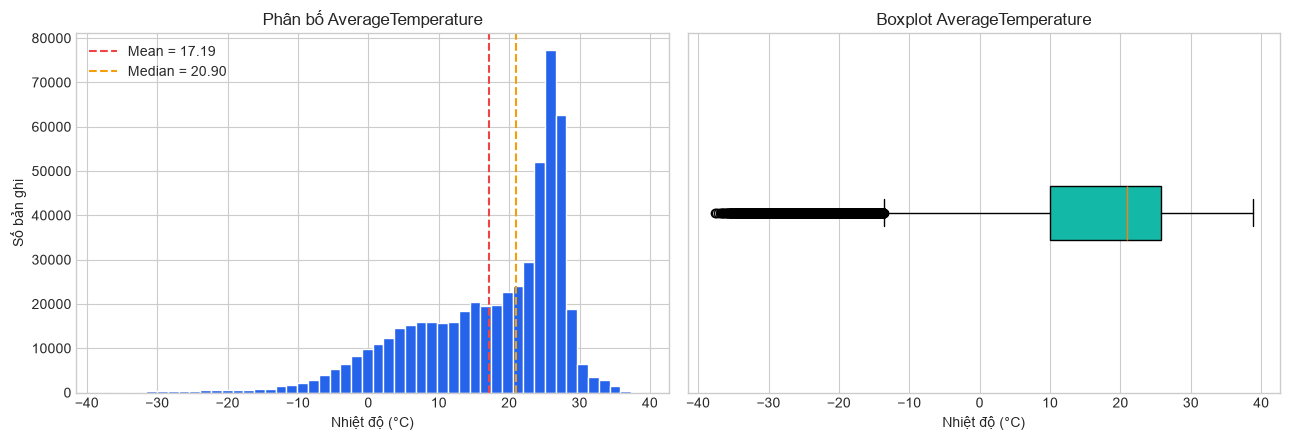

Target missing: 32,651
Target missing (%): 5.65%


In [14]:
target = main_df['AverageTemperature'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(target, bins=50, color='#2563EB', edgecolor='white')
axes[0].axvline(target.mean(), color='#EF4444', linestyle='--', label=f'Mean = {target.mean():.2f}')
axes[0].axvline(target.median(), color='#F59E0B', linestyle='--', label=f'Median = {target.median():.2f}')
axes[0].set_title('Phân bố AverageTemperature')
axes[0].set_xlabel('Nhiệt độ (°C)')
axes[0].set_ylabel('Số bản ghi')
axes[0].legend()

axes[1].boxplot(target, orientation='horizontal', patch_artist=True, boxprops={'facecolor': '#14B8A6'})
axes[1].set_title('Boxplot AverageTemperature')
axes[1].set_xlabel('Nhiệt độ (°C)')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print('Target missing:', f'{main_df["AverageTemperature"].isna().sum():,}')
print('Target missing (%):', f'{main_df["AverageTemperature"].isna().mean() * 100:.2f}%')


### Nhận xét

Target gộp nhiều quốc gia và mùa nên phân phối rộng và có thể nhiều đỉnh. Các điểm ngoài whisker của boxplot chưa chắc là dữ liệu sai; chúng có thể đại diện cho mùa đông ở vùng rất lạnh hoặc mùa hè ở vùng nóng. `Country`, `year` và `month` là các feature ứng viên hợp lý. `AverageTemperatureUncertainty` chỉ nên dùng nếu giá trị này thực sự có sẵn tại thời điểm dự đoán và đã kiểm tra leakage.


# PHẦN B — KHẢO SÁT TOÀN BỘ 5 BẢNG

Các helper dưới đây được tách thành nhiều cell: một cell gộp thống kê số, một cell quét file và một cell thực thi. Cách này dễ đọc và dễ kiểm thử hơn một khối code dài.


## 16. Helper 1 — Gộp thống kê số giữa các chunk


In [15]:
def merge_numeric_state(state, series):
    values = series.dropna().astype('float64')
    if values.empty:
        return state

    count_b = len(values)
    mean_b = values.mean()
    m2_b = ((values - mean_b) ** 2).sum()

    if state is None:
        return {
            'count': count_b, 'mean': mean_b, 'm2': m2_b,
            'min': values.min(), 'max': values.max(),
        }

    count_a = state['count']
    total = count_a + count_b
    delta = mean_b - state['mean']
    state['mean'] += delta * count_b / total
    state['m2'] += m2_b + delta**2 * count_a * count_b / total
    state['count'] = total
    state['min'] = min(state['min'], values.min())
    state['max'] = max(state['max'], values.max())
    return state


### Giải thích code khó

Mỗi chunk có count, mean và tổng bình phương sai lệch riêng (`m2`). Công thức dùng `delta` để gộp hai nhóm mà không giữ toàn bộ số liệu trong RAM. Sau cùng `std = sqrt(m2 / (count - 1))`. Cách này ổn định hơn việc cộng `x²` trực tiếp.


## 17. Helper 2 — Quét một file CSV


In [16]:
KEY_SPECS = {
    'GlobalTemperatures.csv': ['dt'],
    'GlobalLandTemperaturesByCountry.csv': ['dt', 'Country'],
    'GlobalLandTemperaturesByState.csv': ['dt', 'Country', 'State'],
    'GlobalLandTemperaturesByCity.csv': ['dt', 'Country', 'City', 'Latitude', 'Longitude'],
    'GlobalLandTemperaturesByMajorCity.csv': ['dt', 'Country', 'City', 'Latitude', 'Longitude'],
}

def scan_csv(path, chunk_size=250_000):
    sample = pd.read_csv(path, nrows=10_000, low_memory=False)
    columns = sample.columns.tolist()
    numeric_columns = sample.select_dtypes(include='number').columns.tolist()
    dimension_columns = [c for c in columns if c.casefold() in {'city', 'country', 'state'}]
    key_columns = KEY_SPECS[path.name]
    missing_key_columns = [column for column in key_columns if column not in columns]
    if missing_key_columns:
        raise KeyError(
            f'{path.name}: thiếu các cột khóa {missing_key_columns}. '
            f'Các cột thực tế: {columns}'
        )

    row_count = 0
    missing = pd.Series(0, index=columns, dtype='int64')
    numeric_states = {column: None for column in numeric_columns}
    dimension_values = {column: set() for column in dimension_columns}
    unique_dates = set()
    full_hashes = []
    key_hashes = []
    date_min = date_max = None
    invalid_dates = 0

    for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
        row_count += len(chunk)
        missing = missing.add(chunk.isna().sum(), fill_value=0).astype('int64')
        full_hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy('uint64'))
        key_hashes.append(pd.util.hash_pandas_object(chunk[key_columns], index=False).to_numpy('uint64'))

        parsed_dates = pd.to_datetime(chunk['dt'], errors='coerce')
        invalid_dates += int(parsed_dates.isna().sum() - chunk['dt'].isna().sum())
        unique_dates.update(parsed_dates.dropna().unique())
        current_min, current_max = parsed_dates.min(), parsed_dates.max()
        if pd.notna(current_min) and (date_min is None or current_min < date_min):
            date_min = current_min
        if pd.notna(current_max) and (date_max is None or current_max > date_max):
            date_max = current_max

        for column in numeric_columns:
            numeric_states[column] = merge_numeric_state(numeric_states[column], chunk[column])
        for column in dimension_columns:
            dimension_values[column].update(chunk[column].dropna().astype(str).unique())

    all_full_hashes = np.concatenate(full_hashes)
    all_key_hashes = np.concatenate(key_hashes)
    full_duplicates = int(len(all_full_hashes) - len(np.unique(all_full_hashes)))
    key_duplicates = int(len(all_key_hashes) - len(np.unique(all_key_hashes)))

    numeric_summary = []
    for column, state in numeric_states.items():
        std = np.sqrt(state['m2'] / (state['count'] - 1)) if state and state['count'] > 1 else 0
        numeric_summary.append({
            'column': column, 'count': state['count'], 'mean': state['mean'],
            'std': std, 'min': state['min'], 'max': state['max'],
        })

    bytes_per_row = sample.memory_usage(deep=True).sum() / max(len(sample), 1)
    return {
        'file': path.name, 'rows': row_count, 'columns': len(columns),
        'column_names': columns, 'dtypes': sample.dtypes.astype(str).to_dict(),
        'date_min': date_min, 'date_max': date_max, 'invalid_dates': invalid_dates,
        'distinct_dates': unique_dates, 'missing': missing.to_dict(),
        'full_duplicates': full_duplicates, 'key_duplicates': key_duplicates,
        'dimension_values': dimension_values, 'numeric_summary': numeric_summary,
        'estimated_memory_mb': bytes_per_row * row_count / 1024**2,
    }


### Giải thích code khó

- `c.casefold()` giúp nhận diện cột dimension mà không phụ thuộc cách viết hoa/thường và không đổi tên cột raw. Trong năm CSV hiện tại, các cột địa lý dùng PascalCase như `Country`, `State`, `City`.
- Row hash biến mỗi dòng thành số 64-bit để kiểm tra duplicate toàn file với ít RAM hơn. Key hash làm tương tự nhưng chỉ trên các cột khóa logic; đây là kiểm tra kỹ thuật dựa trên hash, không phải thay đổi dữ liệu.
- `np.concatenate()` ghép các hash của từng chunk; `np.unique()` đếm số hash khác nhau.
- Memory của bảng phụ là ước tính từ 10.000 dòng mẫu, vì đọc toàn bộ file City chỉ để đo RAM là không cần thiết.


## 18. Thực thi quét 5 file


In [17]:
scan_results = []
scan_start = time.perf_counter()

for name, path in FILE_PATHS.items():
    start = time.perf_counter()
    result = scan_csv(path, CHUNK_SIZE)
    scan_results.append(result)
    print(f'{name}: {result["rows"]:,} dòng — {time.perf_counter() - start:.2f} giây')

print(f'Tổng thời gian: {time.perf_counter() - scan_start:.2f} giây')


GlobalLandTemperaturesByCity.csv: 8,599,212 dòng — 49.48 giây
GlobalLandTemperaturesByCountry.csv: 577,462 dòng — 2.16 giây
GlobalLandTemperaturesByMajorCity.csv: 239,177 dòng — 1.11 giây
GlobalLandTemperaturesByState.csv: 645,675 dòng — 2.77 giây
GlobalTemperatures.csv: 3,192 dòng — 0.07 giây
Tổng thời gian: 55.60 giây


## 19. Tổng quan bảng phụ và toàn bộ dataset


In [18]:
SHORT_NAMES = {
    'GlobalLandTemperaturesByCity.csv': 'City',
    'GlobalLandTemperaturesByCountry.csv': 'Country',
    'GlobalLandTemperaturesByMajorCity.csv': 'Major City',
    'GlobalLandTemperaturesByState.csv': 'State',
    'GlobalTemperatures.csv': 'Global',
}

overview_df = pd.DataFrame([{
    'file': result['file'],
    'rows': result['rows'],
    'columns': result['columns'],
    'estimated_memory_mb': result['estimated_memory_mb'],
    'date_min': result['date_min'],
    'date_max': result['date_max'],
    'invalid_dates': result['invalid_dates'],
    'full_duplicates': result['full_duplicates'],
    'key_duplicates': result['key_duplicates'],
} for result in scan_results])
display(overview_df)


,file,rows,columns,estimated_memory_mb,date_min,date_max,invalid_dates,full_duplicates,key_duplicates
0,GlobalLandTemperaturesByCity.csv,8599212,7,742.7746,1743-11-01,2013-09-01,0,0,0
1,GlobalLandTemperaturesByCountry.csv,577462,4,27.1694,1743-11-01,2013-09-01,0,0,0
2,GlobalLandTemperaturesByMajorCity.csv,239177,7,21.2278,1743-11-01,2013-09-01,0,0,0
3,GlobalLandTemperaturesByState.csv,645675,5,39.7745,1743-11-01,2013-09-01,0,0,0
4,GlobalTemperatures.csv,3192,9,0.2497,1750-01-01,2015-12-01,0,0,0


### Nhận xét

Số dòng khác nhau mạnh vì grain khác nhau: Global có 3.192 dòng, còn City có 8.599.212 dòng. Cả 5 file đều có 0 ngày không hợp lệ, 0 full duplicate và 0 key duplicate theo các khóa ứng viên đã khai báo. Key duplicate quan trọng hơn full duplicate vì hai dòng có cùng tháng và địa điểm nhưng số đo khác nhau vẫn có thể gây lỗi khi thiết kế primary key PostgreSQL.


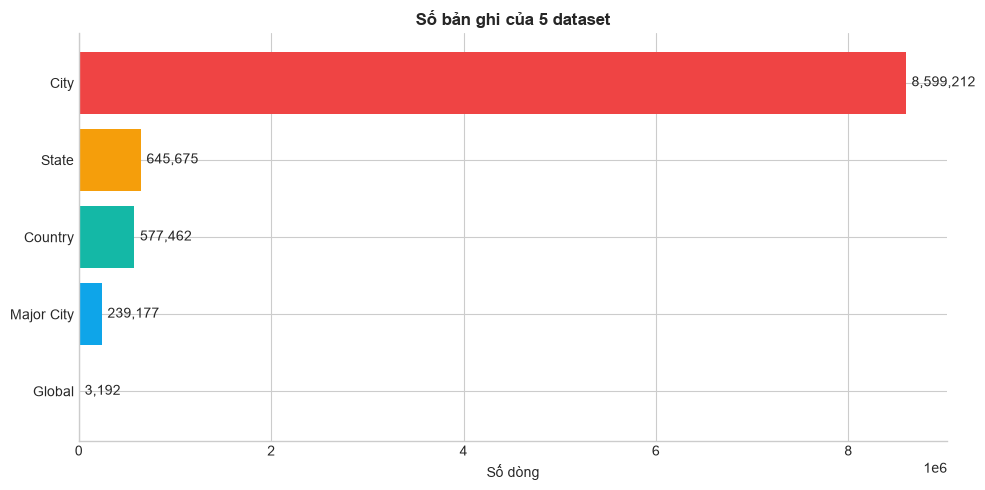

In [19]:
plot_df = overview_df.copy()
plot_df['dataset'] = plot_df['file'].map(SHORT_NAMES)
plot_df = plot_df.sort_values('rows')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_df['dataset'], plot_df['rows'], color=COLORS)
ax.bar_label(bars, labels=[f'{value:,.0f}' for value in plot_df['rows']], padding=4)
ax.set_title('Số bản ghi của 5 dataset', weight='bold')
ax.set_xlabel('Số dòng')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Nhận xét biểu đồ

City là bảng lớn nhất với 8.599.212 dòng và bộ nhớ ước tính khoảng 742,77 MB, nên cần đọc theo chunk và ưu tiên `COPY` khi nhập PostgreSQL; index nên được tạo sau bulk load. Country có 577.462 dòng, phù hợp làm bảng chính cho ML. Global chỉ có 3.192 dòng nhưng mang ý nghĩa benchmark toàn cầu, nên không thể đánh giá vai trò chỉ dựa trên số dòng.


## 20. Missing và phạm vi thời gian của 5 bảng


In [20]:
missing_rows = []
for result in scan_results:
    for column, count in result['missing'].items():
        missing_rows.append({
            'file': result['file'], 'column': column,
            'missing_count': count,
            'missing_percent': count / result['rows'] * 100,
        })

missing_all_df = pd.DataFrame(missing_rows)
missing_nonzero = missing_all_df.query('missing_count > 0').sort_values('missing_percent', ascending=False)
display(missing_nonzero)


,file,column,missing_count,missing_percent
28,GlobalTemperatures.csv,LandMinTemperature,1200,37.5940
29,GlobalTemperatures.csv,LandMinTemperatureUncertainty,1200,37.5940
31,GlobalTemperatures.csv,LandAndOceanAverageTemperatureUncertainty,1200,37.5940
30,GlobalTemperatures.csv,LandAndOceanAverageTemperature,1200,37.5940
26,GlobalTemperatures.csv,LandMaxTemperature,1200,37.5940
27,GlobalTemperatures.csv,LandMaxTemperatureUncertainty,1200,37.5940
8,GlobalLandTemperaturesByCountry.csv,AverageTemperature,32651,5.6542
9,GlobalLandTemperaturesByCountry.csv,AverageTemperatureUncertainty,31912,5.5263
12,GlobalLandTemperaturesByMajorCity.csv,AverageTemperature,11002,4.5999
13,GlobalLandTemperaturesByMajorCity.csv,AverageTemperatureUncertainty,11002,4.5999


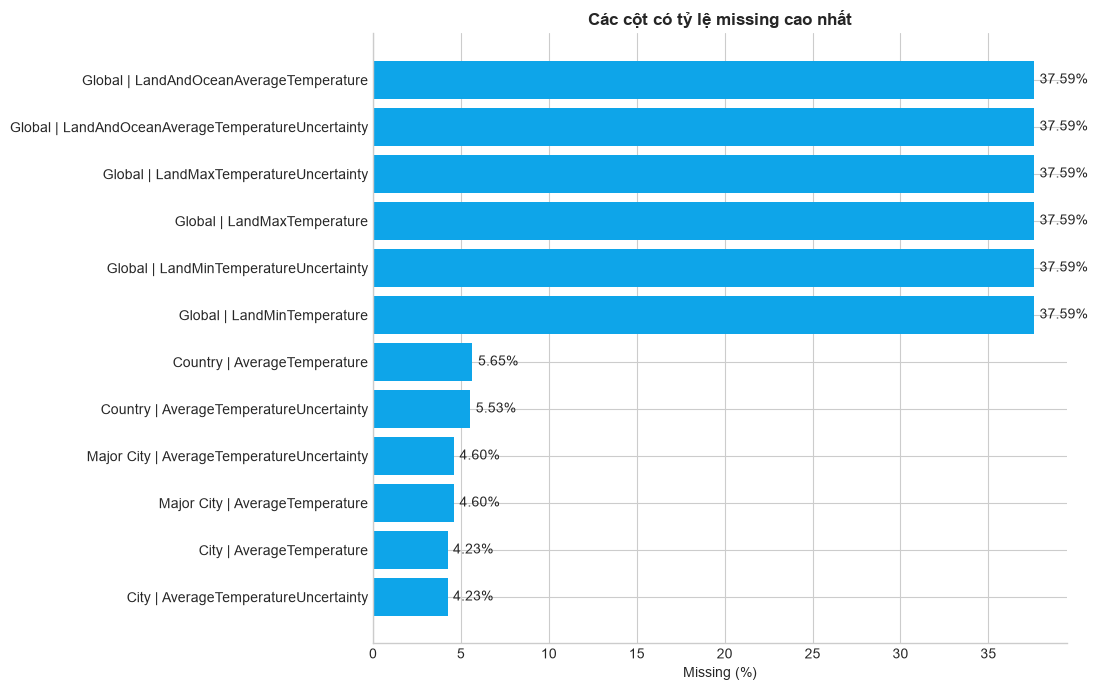

In [21]:
top_missing = missing_nonzero.nlargest(12, 'missing_percent').copy()
top_missing['label'] = top_missing['file'].map(SHORT_NAMES) + ' | ' + top_missing['column']
top_missing = top_missing.sort_values('missing_percent')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_missing['label'], top_missing['missing_percent'], color='#0EA5E9')
ax.bar_label(bars, labels=[f'{value:.2f}%' for value in top_missing['missing_percent']], padding=4)
ax.set_title('Các cột có tỷ lệ missing cao nhất', weight='bold')
ax.set_xlabel('Missing (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Nhận xét missing

Missing khác rõ theo bảng và giai đoạn. Sáu cột Global về nhiệt độ cực đại, cực tiểu và kết hợp đất–đại dương đều thiếu 1.200 tháng (37,594%) trong giai đoạn 1750-01 đến 1849-12; `LandAverageTemperature` và uncertainty tương ứng chỉ thiếu 12 tháng. Target thiếu 5,6542% ở Country, 4,5999% ở Major City, 4,2345% ở City và 3,9723% ở State. Vì vậy Notebook 03 không nên áp dụng một công thức `fillna()` chung cho mọi bảng hoặc mọi thời kỳ.


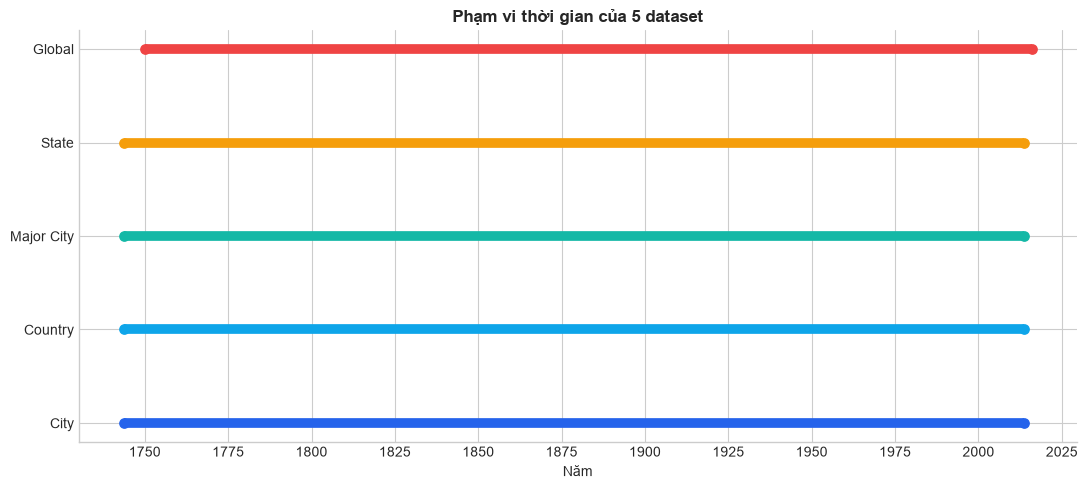

In [22]:
timeline = overview_df.copy()
timeline['dataset'] = timeline['file'].map(SHORT_NAMES)

fig, ax = plt.subplots(figsize=(11, 5))
for position, row in timeline.reset_index(drop=True).iterrows():
    ax.hlines(position, row['date_min'], row['date_max'], color=COLORS[position], linewidth=7)
    ax.scatter([row['date_min'], row['date_max']], [position, position], color=COLORS[position], s=45)

ax.set_yticks(range(len(timeline)), timeline['dataset'])
ax.xaxis.set_major_locator(mdates.YearLocator(25))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Phạm vi thời gian của 5 dataset', weight='bold')
ax.set_xlabel('Năm')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Nhận xét thời gian

Bốn bảng địa lý Country, State, City và Major City cùng bao phủ 1743-11 đến 2013-09, còn Global bao phủ 1750-01 đến 2015-12. Chênh lệch phạm vi này không phải lỗi làm sạch. Mỗi bảng nên giữ lịch sử phù hợp với mục tiêu; chỉ giới hạn về giai đoạn giao nhau khi một phép so sánh hoặc join cụ thể yêu cầu. Nếu cắt tất cả về cùng năm quá sớm, dự án sẽ mất giá trị phân tích dài hạn.


## 21. Kiểm tra quan hệ giữa các bảng

Notebook thực hiện `LEFT JOIN` kiểm tra theo chunk để không phải giữ bảng City 8,6 triệu dòng trong RAM. State, City và Major City được nối với Country theo khóa ghép `dt + Country`; Country được nối với Global theo `dt`. Mỗi phép join dùng `validate='many_to_one'` và đo số dòng trước/sau, unmatched cùng row multiplication, nhưng không lưu một flat table mới ở bước Data Understanding.


In [23]:
result_by_file = {result['file']: result for result in scan_results}

# Chuẩn bị các bảng khóa phía "one" của phép many-to-one join.
country_key_table = pd.read_csv(
    FILE_PATHS['GlobalLandTemperaturesByCountry.csv'],
    usecols=['dt', 'Country'],
    low_memory=False,
)
global_key_table = pd.read_csv(
    FILE_PATHS['GlobalTemperatures.csv'],
    usecols=['dt'],
    low_memory=False,
)

# Xác nhận khóa phía parent là duy nhất trước khi dùng validate='many_to_one'.
country_parent_duplicates = int(
    country_key_table.duplicated(['dt', 'Country']).sum()
)
global_parent_duplicates = int(
    global_key_table.duplicated(['dt']).sum()
)
if country_parent_duplicates or global_parent_duplicates:
    raise ValueError(
        'Parent key bị trùng: '
        f'Country={country_parent_duplicates}, Global={global_parent_duplicates}'
    )

country_coverage = (
    country_key_table.groupby('Country', as_index=False)
    .agg(
        parent_min_date=('dt', 'min'),
        parent_max_date=('dt', 'max'),
    )
)
global_min_date = global_key_table['dt'].min()
global_max_date = global_key_table['dt'].max()


def validate_chunked_join(
    relationship,
    source_path,
    parent_keys,
    join_columns,
    expected_unmatched_mode,
    chunk_size=CHUNK_SIZE,
):
    """LEFT JOIN theo chunk và kiểm tra mất dòng, nhân dòng, unmatched."""
    parent = parent_keys.copy()
    parent['_parent_match'] = True

    source_rows = 0
    joined_rows = 0
    matched_rows = 0
    expected_unmatched_rows = 0
    unexpected_unmatched_rows = 0

    for chunk in pd.read_csv(
        source_path,
        usecols=join_columns,
        chunksize=chunk_size,
        low_memory=False,
    ):
        joined = chunk.merge(
            parent,
            on=join_columns,
            how='left',
            sort=False,
            validate='many_to_one',
        )
        is_matched = joined['_parent_match'].fillna(False).astype(bool)

        if expected_unmatched_mode == 'country_coverage':
            joined = joined.merge(
                country_coverage,
                on='Country',
                how='left',
                sort=False,
                validate='many_to_one',
            )
            is_expected_unmatched = (
                ~is_matched
                & joined['parent_min_date'].notna()
                & (
                    (joined['dt'] < joined['parent_min_date'])
                    | (joined['dt'] > joined['parent_max_date'])
                )
            )
        elif expected_unmatched_mode == 'global_range':
            is_expected_unmatched = (
                ~is_matched
                & (
                    (joined['dt'] < global_min_date)
                    | (joined['dt'] > global_max_date)
                )
            )
        else:
            raise ValueError(
                f'Unsupported unmatched mode: {expected_unmatched_mode}'
            )

        source_rows += len(chunk)
        joined_rows += len(joined)
        matched_rows += int(is_matched.sum())
        expected_unmatched_rows += int(is_expected_unmatched.sum())
        unexpected_unmatched_rows += int(
            ((~is_matched) & (~is_expected_unmatched)).sum()
        )

    row_multiplication = joined_rows - source_rows
    match_rate = matched_rows / source_rows * 100 if source_rows else 0.0
    status = (
        'PASS'
        if row_multiplication == 0 and unexpected_unmatched_rows == 0
        else 'REVIEW'
    )

    return {
        'relationship': relationship,
        'join_key': ' + '.join(join_columns),
        'source_rows': source_rows,
        'joined_rows': joined_rows,
        'matched_rows': matched_rows,
        'expected_unmatched_rows': expected_unmatched_rows,
        'unexpected_unmatched_rows': unexpected_unmatched_rows,
        'row_multiplication': row_multiplication,
        'match_rate_percent': match_rate,
        'status': status,
    }


relationship_specs = [
    (
        'State → Country',
        FILE_PATHS['GlobalLandTemperaturesByState.csv'],
        country_key_table,
        ['dt', 'Country'],
        'country_coverage',
    ),
    (
        'City → Country',
        FILE_PATHS['GlobalLandTemperaturesByCity.csv'],
        country_key_table,
        ['dt', 'Country'],
        'country_coverage',
    ),
    (
        'Major City → Country',
        FILE_PATHS['GlobalLandTemperaturesByMajorCity.csv'],
        country_key_table,
        ['dt', 'Country'],
        'country_coverage',
    ),
    (
        'Country → Global',
        FILE_PATHS['GlobalLandTemperaturesByCountry.csv'],
        global_key_table,
        ['dt'],
        'global_range',
    ),
]

relationship_df = pd.DataFrame(
    validate_chunked_join(*specification)
    for specification in relationship_specs
)
display(relationship_df)

,relationship,join_key,source_rows,joined_rows,matched_rows,expected_unmatched_rows,unexpected_unmatched_rows,row_multiplication,match_rate_percent,status
0,State → Country,dt + Country,645675,645675,591003,54672,0,0,91.5326,PASS
1,City → Country,dt + Country,8599212,8599212,8418686,180526,0,0,97.9007,PASS
2,Major City → Country,dt + Country,239177,239177,233506,5671,0,0,97.6290,PASS
3,Country → Global,dt,577462,577462,573762,3700,0,0,99.3593,PASS


### Giải thích và nhận xét

`validate='many_to_one'` yêu cầu khóa phía parent phải duy nhất; nếu parent có duplicate key, pandas sẽ dừng thay vì âm thầm nhân dòng. Cả bốn phép join đều giữ nguyên số dòng nguồn (`source_rows = joined_rows`), có `row_multiplication = 0` và không có unmatched ngoài dự kiến, nên nhận trạng thái `PASS`.

Các unmatched được phân loại là có thể giải thích bởi phạm vi lịch sử của bảng parent:

- State → Country: khớp 591.003/645.675 dòng; 54.672 dòng ngoài phạm vi thời gian riêng của Country tương ứng.
- City → Country: khớp 8.418.686/8.599.212 dòng; 180.526 dòng ngoài phạm vi thời gian riêng của Country tương ứng.
- Major City → Country: khớp 233.506/239.177 dòng; 5.671 dòng ngoài phạm vi thời gian riêng của Country tương ứng.
- Country → Global: khớp 573.762/577.462 dòng; 3.700 dòng nằm ngoài phạm vi 1750-01 đến 2015-12 của Global.

Về cardinality, Country → State/City/Major City và Global → Country đều là quan hệ 1–N theo khóa phân tích nêu trên. City và Major City là hai bảng fact độc lập; nếu cần đối chiếu chúng, phải dùng `dt + Country + City + Latitude + Longitude` thay vì chỉ tên City. Không được nối trực tiếp các bảng 1–N để tạo flat table ML cấp Country; cần aggregate bảng phụ về một dòng cho mỗi `dt + Country` trước khi join.


## 22. Đánh giá sơ bộ các nhóm cột quan trọng


In [24]:
initial_feature_assessment = pd.DataFrame([
    ['AverageTemperature', 'Target', 'Giữ làm biến cần dự đoán; xử lý missing có kiểm soát'],
    ['AverageTemperatureUncertainty', 'Quality / numeric feature', 'Kiểm tra missing và phân phối theo thời gian'],
    ['dt', 'Time key', 'Chuyển datetime; tạo year, month, decade ở Notebook 05'],
    ['Country', 'Category / location key', 'Chuẩn hóa tên; encoding trong pipeline ML'],
    ['Latitude, Longitude', 'Geospatial feature', 'Đổi N/S/E/W thành số có dấu nếu dùng City'],
    ['Global temperature measures', 'External benchmark feature', 'Chỉ join theo dt sau khi kiểm tra leakage và grain'],
], columns=['column_or_group', 'assumed_role', 'next_action'])
display(initial_feature_assessment)


,column_or_group,assumed_role,next_action
0,AverageTemperature,Target,Giữ làm biến cần dự đoán; xử lý missing có kiể...
1,AverageTemperatureUncertainty,Quality / numeric feature,Kiểm tra missing và phân phối theo thời gian
2,dt,Time key,"Chuyển datetime; tạo year, month, decade ở Not..."
3,Country,Category / location key,Chuẩn hóa tên; encoding trong pipeline ML
4,"Latitude, Longitude",Geospatial feature,Đổi N/S/E/W thành số có dấu nếu dùng City
5,Global temperature measures,External benchmark feature,Chỉ join theo dt sau khi kiểm tra leakage và g...


### Nhận xét

Các vai trò trên là giả thuyết ban đầu, chưa phải feature selection cuối cùng. Notebook 04 sẽ kiểm chứng quan hệ bằng EDA; Notebook 05 mới tạo và đánh giá feature. Đặc biệt, uncertainty và các thước đo Global chỉ được dùng nếu có sẵn tại thời điểm dự đoán, đúng grain và không gây target leakage. Không nên encoding hoặc scale ở Notebook 01.


## 23. Chuẩn bị cho Notebook 02 — PostgreSQL Pipeline

1. Tạo 5 bảng staging độc lập, giữ đúng grain và schema của từng CSV raw.
2. Mapping tên cột về `snake_case` nhưng không sửa CSV raw.
3. Dùng `COPY` cho bảng City nguyên bản 8.599.212 dòng; việc chọn 80 quốc gia và giai đoạn 1863–2013 được thực hiện sau import trong Notebook 02, không thay đổi CSV raw.
4. Đối chiếu `COUNT(*)` ngay sau import với row count raw từ notebook này, sau đó ghi riêng row count sau từng bước lọc.
5. Tạo index theo các candidate key: ngày, quốc gia, bang, thành phố.
6. Không join trực tiếp toàn bộ City/State vào Country. Nếu cần ML cấp Country, phải aggregate bảng phụ về grain `Country + dt` trước.
7. Notebook 03 trở đi đọc từ PostgreSQL, không quay lại đọc CSV.


## 24. Pipeline toàn dự án

```text
01 Data Understanding
        ↓
02 PostgreSQL & Data Pipeline
        ↓
03 Data Cleaning
        ↓
04 EDA & Visualization
        ↓
05 Feature Engineering
        ↓
06 Machine Learning
        ↓
07 Prediction Demo / Deployment
```


## 25. Kết luận


1. DỮ LIỆU ĐANG CÓ LÀ GÌ?
- Có 5 bảng nhiệt độ với tổng 10,064,718 bản ghi đang đọc được.
- Bảng chính: Country; target: AverageTemperature; grain: quốc gia-tháng.

2. DỮ LIỆU CÓ ĐÁNG TIN CẬY KHÔNG?
- Full duplicate: 0; key duplicate: 0.
- Có missing ở một số cột nhiệt độ/uncertainty; cần xử lý theo địa điểm và thời gian.
- Cả 5 file vượt qua kiểm tra nhanh số trường ở dòng cuối.

3. DỮ LIỆU ĐƯỢC TỔ CHỨC VÀ LIÊN KẾT NHƯ THẾ NÀO?
- Năm bảng fact ở các grain Global, Country, State, City và Major City.
- Bốn phép join kiểm tra đều không làm mất/nhân dòng và không có unmatched ngoài phạm vi thời gian dự kiến.
- Chỉ join theo câu hỏi cụ thể; aggregate bảng 1–N về đúng grain trước khi tạo flat table.

4. CẦN CHUẨN BỊ GÌ TIẾP THEO?
- Tạo 5 bảng PostgreSQL, kiểm tra row count, key, index và quan hệ.
- Dữ liệu raw có thể chứa missing; việc làm sạch thuộc Notebook 03.

### Nhận xét cuối cùng

Bộ dữ liệu phù hợp để tiếp tục dự án vì có lịch sử dài, nhiều cấp địa lý và target rõ ràng. Điểm khó chính nằm ở sự khác nhau về grain, phạm vi thời gian, cấu trúc cột theo cấp địa lý, tọa độ đang ở dạng chuỗi và missing theo lịch sử; schema raw hiện tại không có sự khác biệt chữ hoa/thường giữa City và các bảng địa lý khác. Thiết kế hợp lý là giữ 5 bảng staging riêng trong PostgreSQL, chọn Country làm bảng ML chính và chỉ aggregate/join bảng phụ khi đã xác định mục đích.

Notebook 01 mới chỉ đánh giá ban đầu. Không xóa outlier, không fill missing, không encoding và không kết luận quan hệ nhân quả ở bước này. Các giả thuyết phải được kiểm chứng trong Notebook 03–05.


## 26. Checklist hoàn thành Notebook 01

- [x] Giới thiệu bài toán AI và target.
- [x] Danh sách 5 file, bảng chính, bảng phụ, vai trò và grain.
- [x] Data Dictionary.
- [x] Shape, memory, columns, info, dtype, nunique và Unique Ratio của bảng chính.
- [x] Describe: count, mean, median, std, min, max và phân vị.
- [x] Missing, duplicate, khóa logic và giá trị bất thường.
- [x] Category, Date và Target.
- [x] Khảo sát các bảng phụ bằng chunk.
- [x] Kiểm tra candidate key và duplicate key.
- [x] Kiểm tra `LEFT JOIN`, unmatched, mất dòng và row multiplication.
- [x] Xác định quan hệ 1–N và cảnh báo row explosion.
- [x] Đánh giá cột quan trọng và kế hoạch Feature Engineering.
- [x] Kết luận và chuẩn bị cho Notebook 02.
